In [73]:
import tensorflow

In [74]:
#pip install tensorflow
#pip install scipy

In [75]:
from keras.models import Sequential
from keras.layers import Conv2D , Dense , MaxPooling2D , Flatten , Dropout

In [76]:
cnn = Sequential()  #modal

In [77]:
cnn = Sequential()

cnn.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
cnn.add(MaxPooling2D(2,2))

cnn.add(Conv2D(64, (3,3), activation='relu'))
cnn.add(MaxPooling2D(2,2))

cnn.add(Conv2D(128, (3,3), activation='relu'))
cnn.add(MaxPooling2D(2,2))

cnn.add(Flatten())

cnn.add(Dense(128, activation='relu'))
cnn.add(Dropout(0.5))

cnn.add(Dense(1, activation='sigmoid'))

In [78]:
from tensorflow.keras.optimizers import Adam


In [79]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [81]:
train_datagen = ImageDataGenerator(rescale =1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)
test_datagen = ImageDataGenerator(rescale =1./255)

train_genrator = train_datagen.flow_from_directory(r'C:\Users\Admin\Documents\Python\CNN\dogs-vs-cats-classification\train',
                                                   target_size = (128,128),
                                                   batch_size = 32,
                                                   class_mode = 'binary')
test_genrator = test_datagen.flow_from_directory(r'C:\Users\Admin\Documents\Python\CNN\dogs-vs-cats-classification\test',
                                                 target_size = (128,128),
                                                 batch_size = 32,
                                                 class_mode = 'binary')
cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
steps_per_epoch = train_genrator.samples // train_genrator.batch_size
validation_steps = test_genrator.samples // test_genrator.batch_size

cnn.fit(
    train_genrator,
    steps_per_epoch=steps_per_epoch,
    validation_data=test_genrator,
    validation_steps=validation_steps,
    epochs=10
)

Found 19943 images belonging to 2 classes.
Found 2495 images belonging to 2 classes.
Epoch 1/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 99s 156ms/step - accuracy: 0.6034 - loss: 0.6568 - val_accuracy: 0.6960 - val_loss: 0.5839
Epoch 2/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6250 - loss: 0.6079 - val_accuracy: 0.6976 - val_loss: 0.5838
Epoch 3/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 96s 153ms/step - accuracy: 0.7086 - loss: 0.5689 - val_accuracy: 0.7553 - val_loss: 0.5059
Epoch 4/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8438 - loss: 0.4609 - val_accuracy: 0.7492 - val_loss: 0.5047
Epoch 5/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 96s 155ms/step - accuracy: 0.7393 - loss: 0.5305 - val_accuracy: 0.7691 - val_loss: 0.4686
Epoch 6/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7188 - loss: 0.5733 - val_accuracy: 0.7735 - val_loss: 0.4709
Epoch 7/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 97s 156ms/step - accuracy: 0.7527 - loss: 0.5064 - val_accuracy: 0.7601 - val_loss: 0.4670
Epoch 8

In [46]:
#pip install scipy

In [82]:
print(train_genrator.samples)
print(test_genrator.samples)
print(train_genrator.class_indices)

19943
2495
{'cats': 0, 'dogs': 1}


In [83]:
import numpy as np
unique, counts = np.unique(train_genrator.classes, return_counts=True)
print(dict(zip(unique, counts)))

{np.int32(0): np.int64(9977), np.int32(1): np.int64(9966)}


In [84]:
x, y = next(train_genrator)
print(x.shape)
print(y[:10])

(32, 128, 128, 3)
[1. 1. 0. 0. 1. 0. 0. 1. 1. 1.]


In [85]:
cnn.save("model.h5")

In [86]:
from keras.preprocessing import image

In [96]:
img = image.load_img(r"C:\Users\Admin\Documents\Python\CNN\dogs-vs-cats-classification\test\dogs\dog_test_00035.jpg",target_size=(128,128))

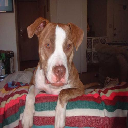

In [97]:
img

In [98]:
img = image.img_to_array(img)

In [99]:
import numpy as np
img = np.expand_dims(img,axis = 0)

In [100]:
pred = cnn.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [92]:
if pred[0][0] < 0.5 :
    print("cat")
else : 
    print("dog")

cat


In [95]:
#img

In [94]:
#pip install flask
